# Combined Model Chromatin Deconvolution

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.DG1Analysis import DG1Analysis

output_directory = 'output/prototype_pipeline_subset'
dg1_analysis = DG1Analysis(output_directory)


Loading configs from replication runs:  output/prototype_pipeline_subset/single_replication/
Shifting mu0, gamma1, and gamma2, for alpha...


# Analysis of chromatin deconvolution

1. Start with sanity checks, show that we are able to load any of the deconvolution windows

In [3]:
dg1_analysis.load_chromatin_measures()

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


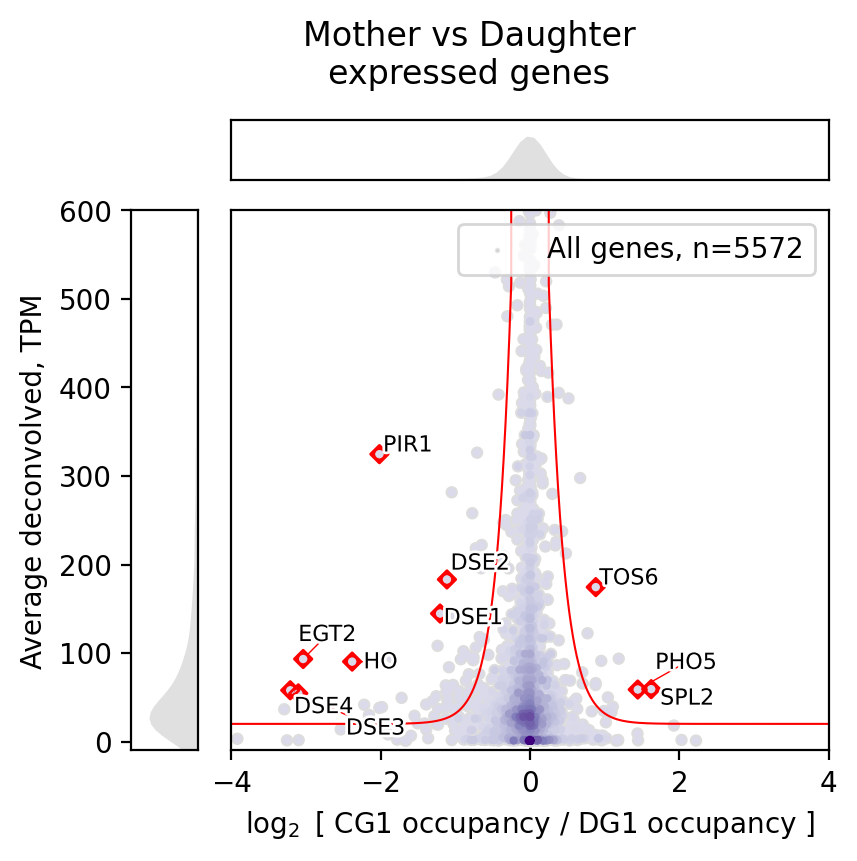

In [4]:
from pipeline.expression_analysis import ExpressionAnalysis
analysis = ExpressionAnalysis(output_directory)
analysis.plot_volcano_cg1_dg1(genes_callout=['DSE1', 'DSE2', 'DSE3', 'DSE4', 'PHO5',
                                            'HO', 'SPL2', 'PIR1', 'EGT2', 'TOS6'])


In [6]:
from src.geneset import get_deconvolved_geneset
genes = get_deconvolved_geneset()


In [7]:
dg1_cg1_sm_prom_gene_data = analysis.cg1_dg1_data.sort_values('max_ratio').join(genes[['gene']])

In [8]:
dg1_analysis.define_subsets(analysis)

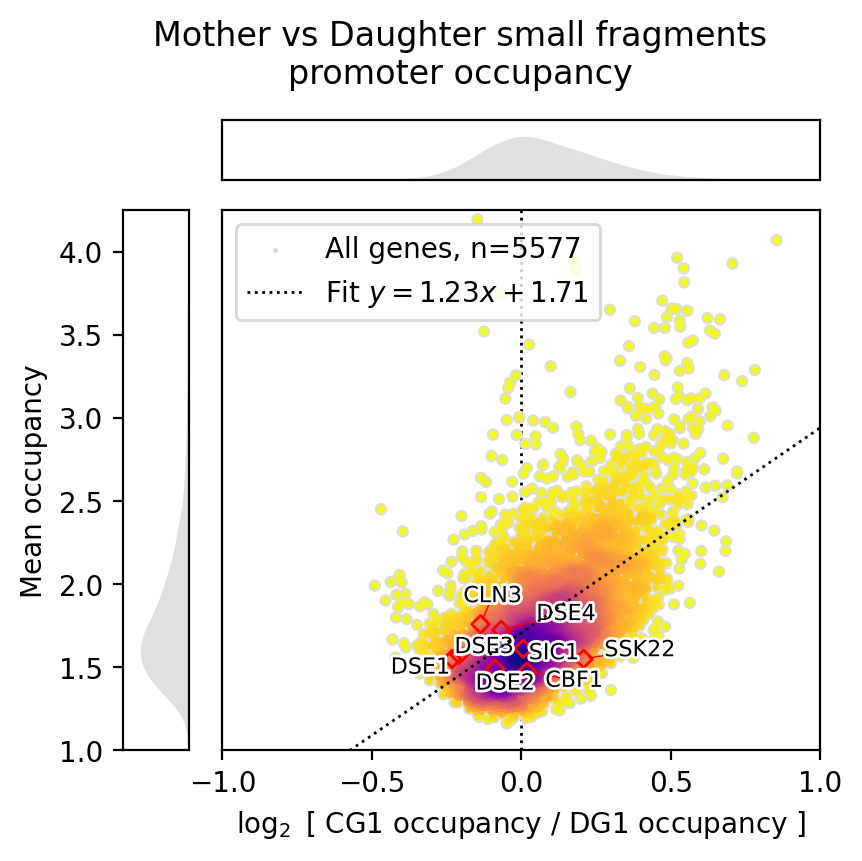

In [9]:
dg1_analysis.plot_dg1_vs_cg1()

In [ ]:
# dg1_analysis.plot_subset_dg1_tx()
# dg1_analysis.plot_subset_cg1_tx()

In [10]:
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis

genome_analysis = GenomeDeconvolutionAnalysis(outdir=
    f"{output_directory}/chromatin_deconvolution/deconvolution_data")

In [12]:
dg1_cg1_sm_prom_gene_data[dg1_cg1_sm_prom_gene_data.average_TPM > 70].head(3)

,average_TPM,max_ratio,gene
YNL327W,93.292382,-3.035351,EGT2
YDL227C,90.354081,-2.379897,HO
YKL164C,324.682728,-2.015116,PIR1


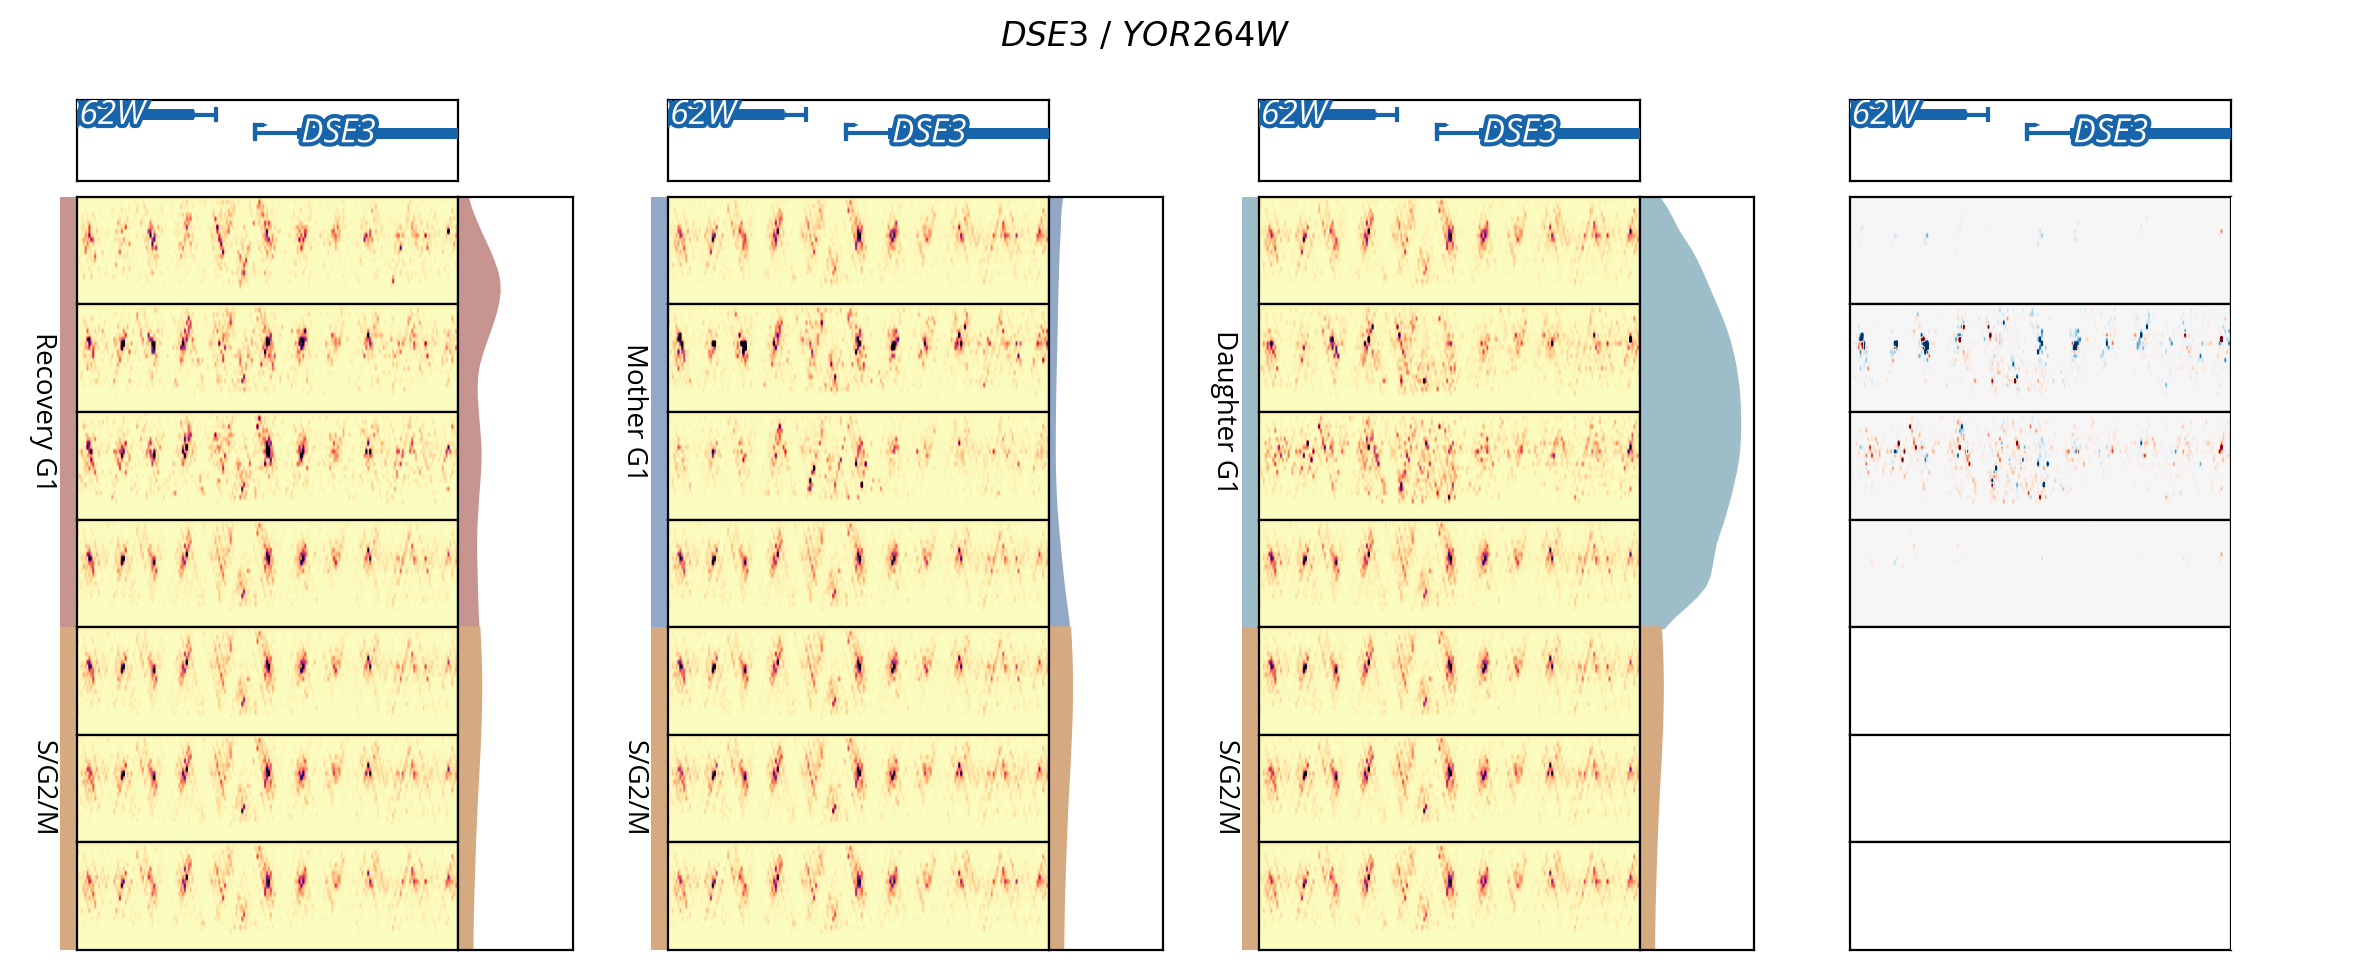

In [14]:
from src.config import load_default_chrom_configs

config1, config2 = load_default_chrom_configs()

fig = genome_analysis.plot_gene('DSE3', config1, analysis)

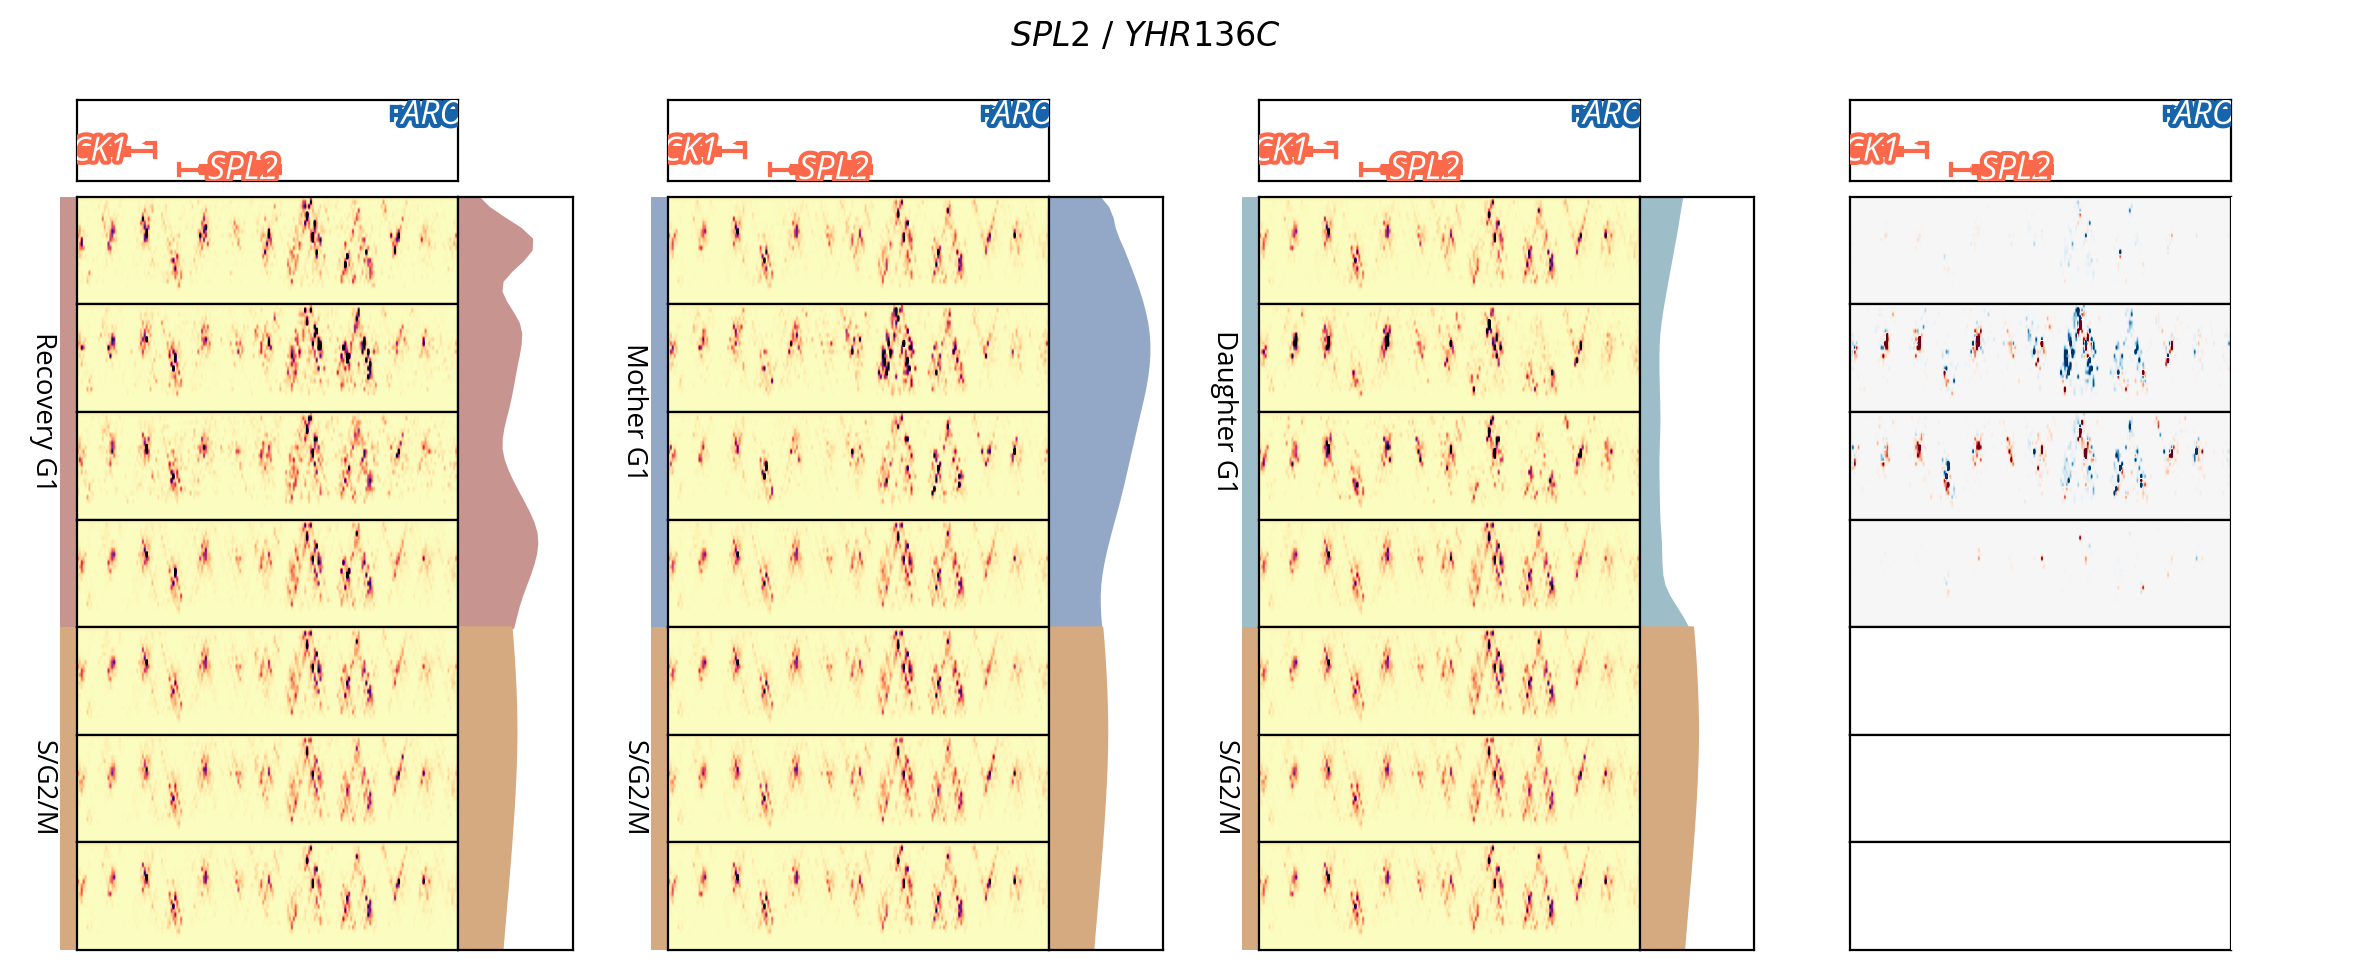

In [15]:
fig = genome_analysis.plot_gene('SPL2', config1, analysis)

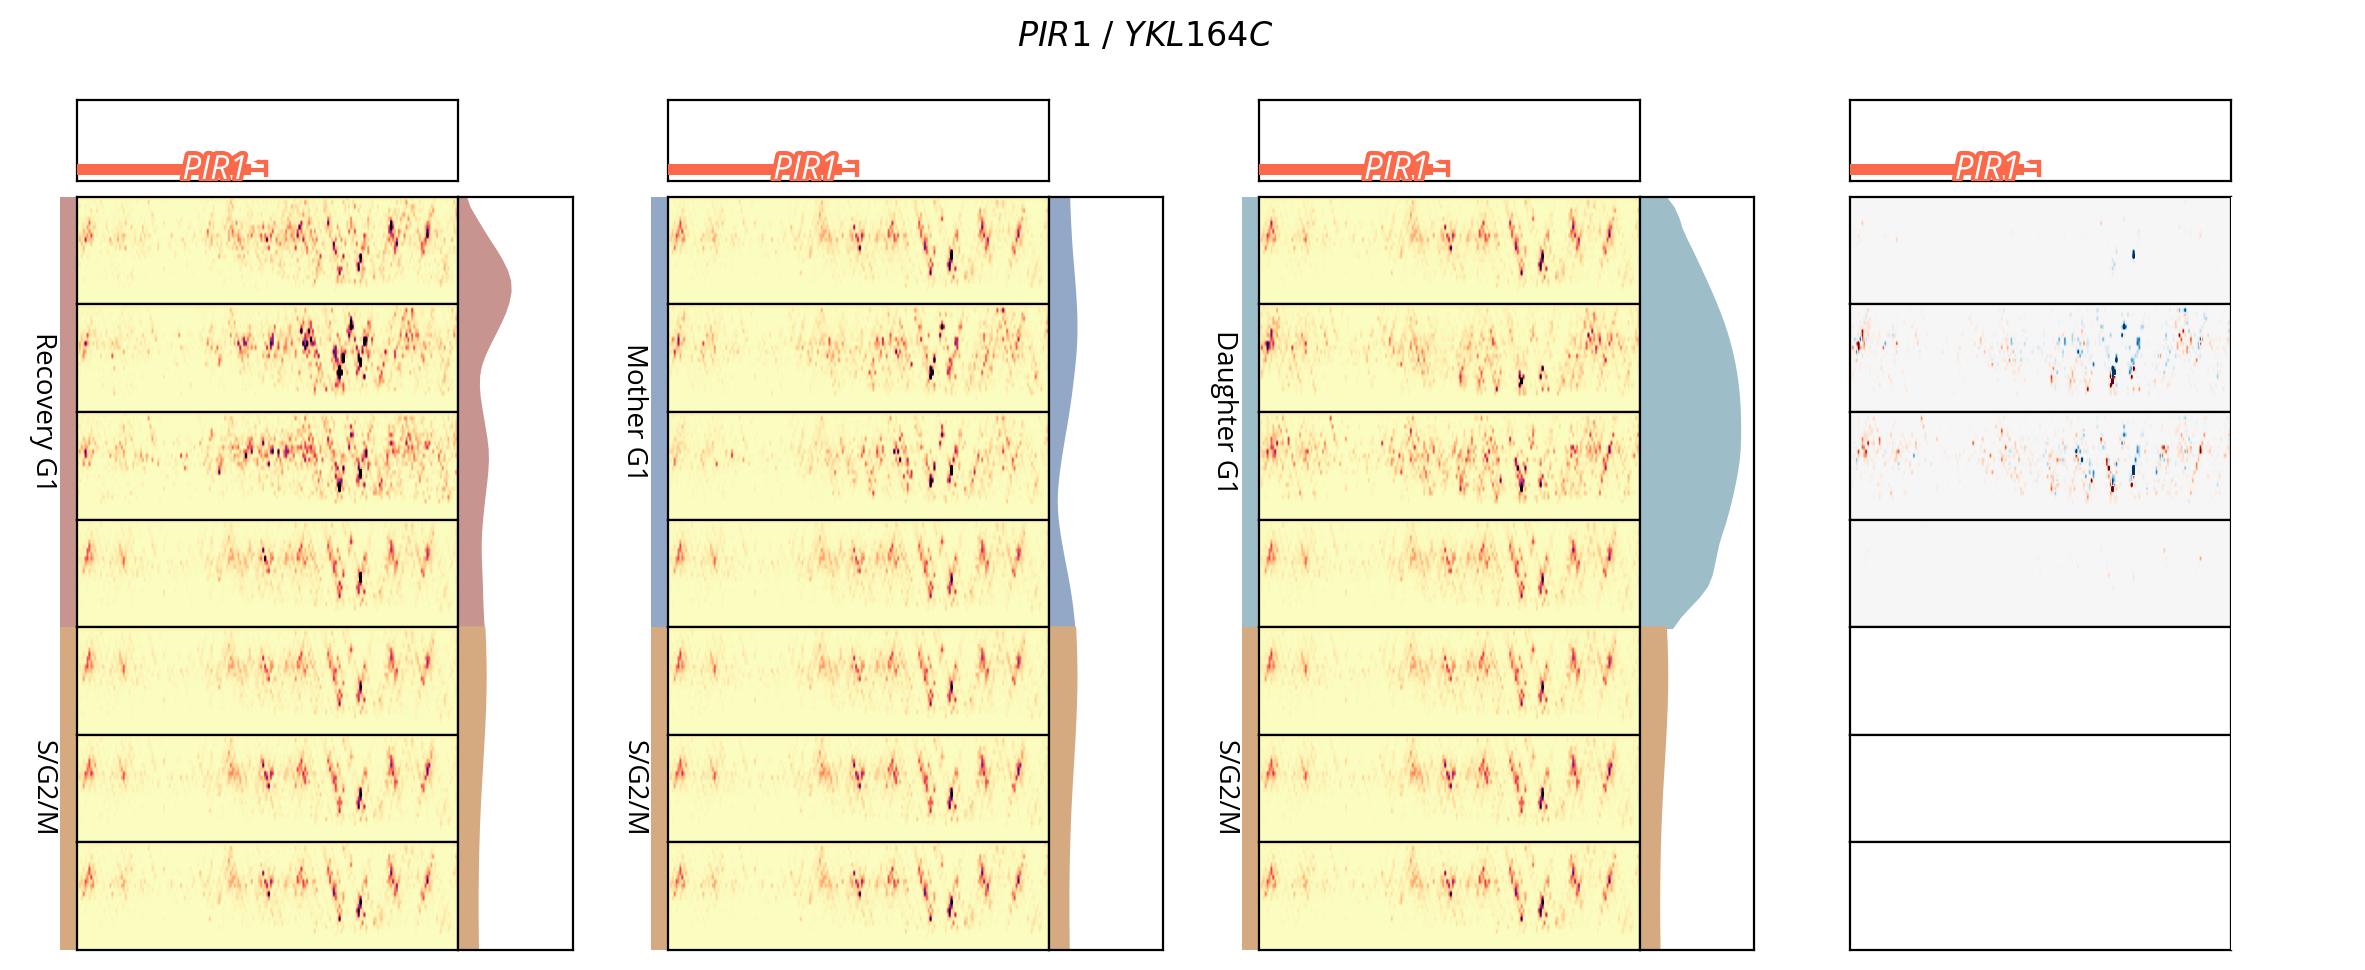

In [16]:
fig = genome_analysis.plot_gene('PIR1', config1, analysis)

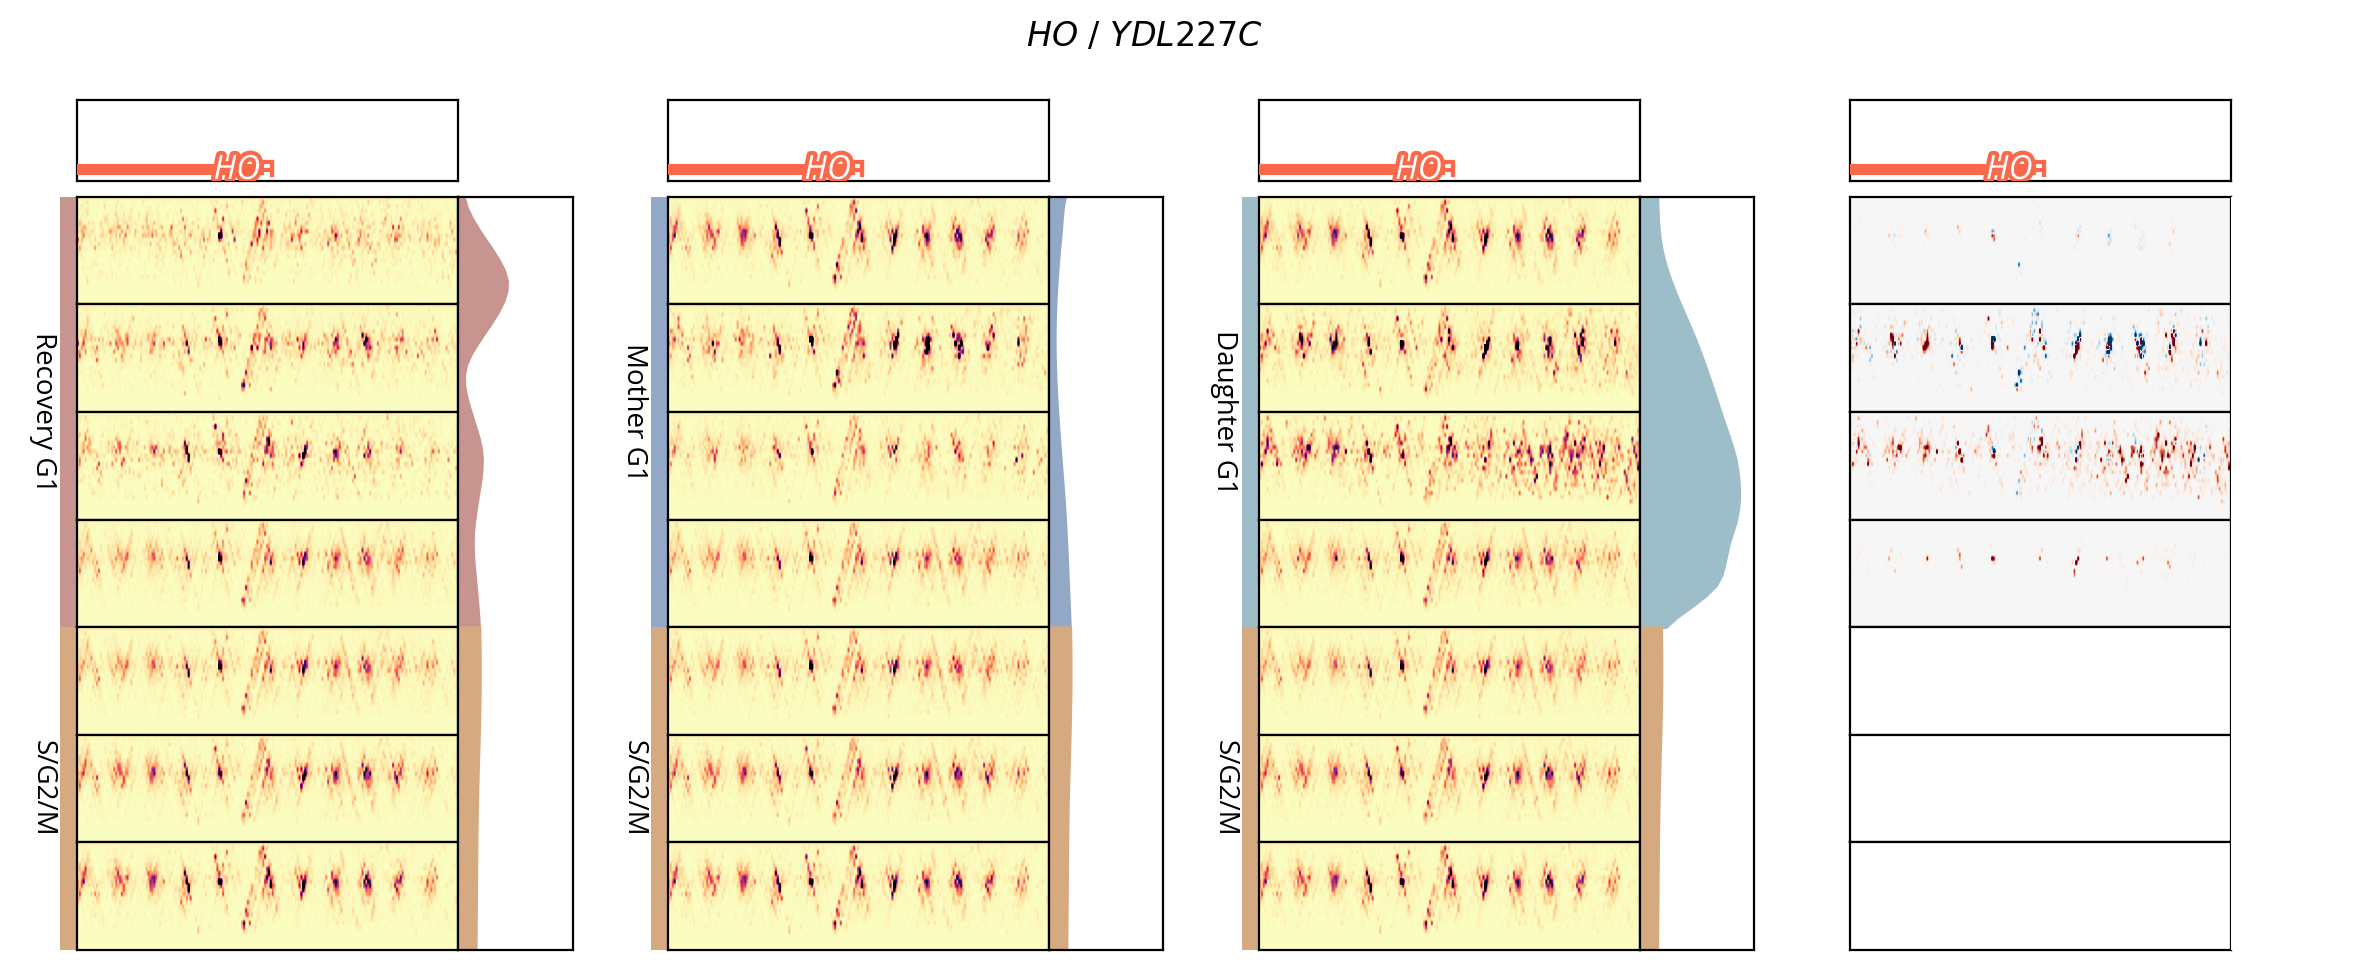

In [17]:
fig = genome_analysis.plot_gene('HO', config1, analysis)

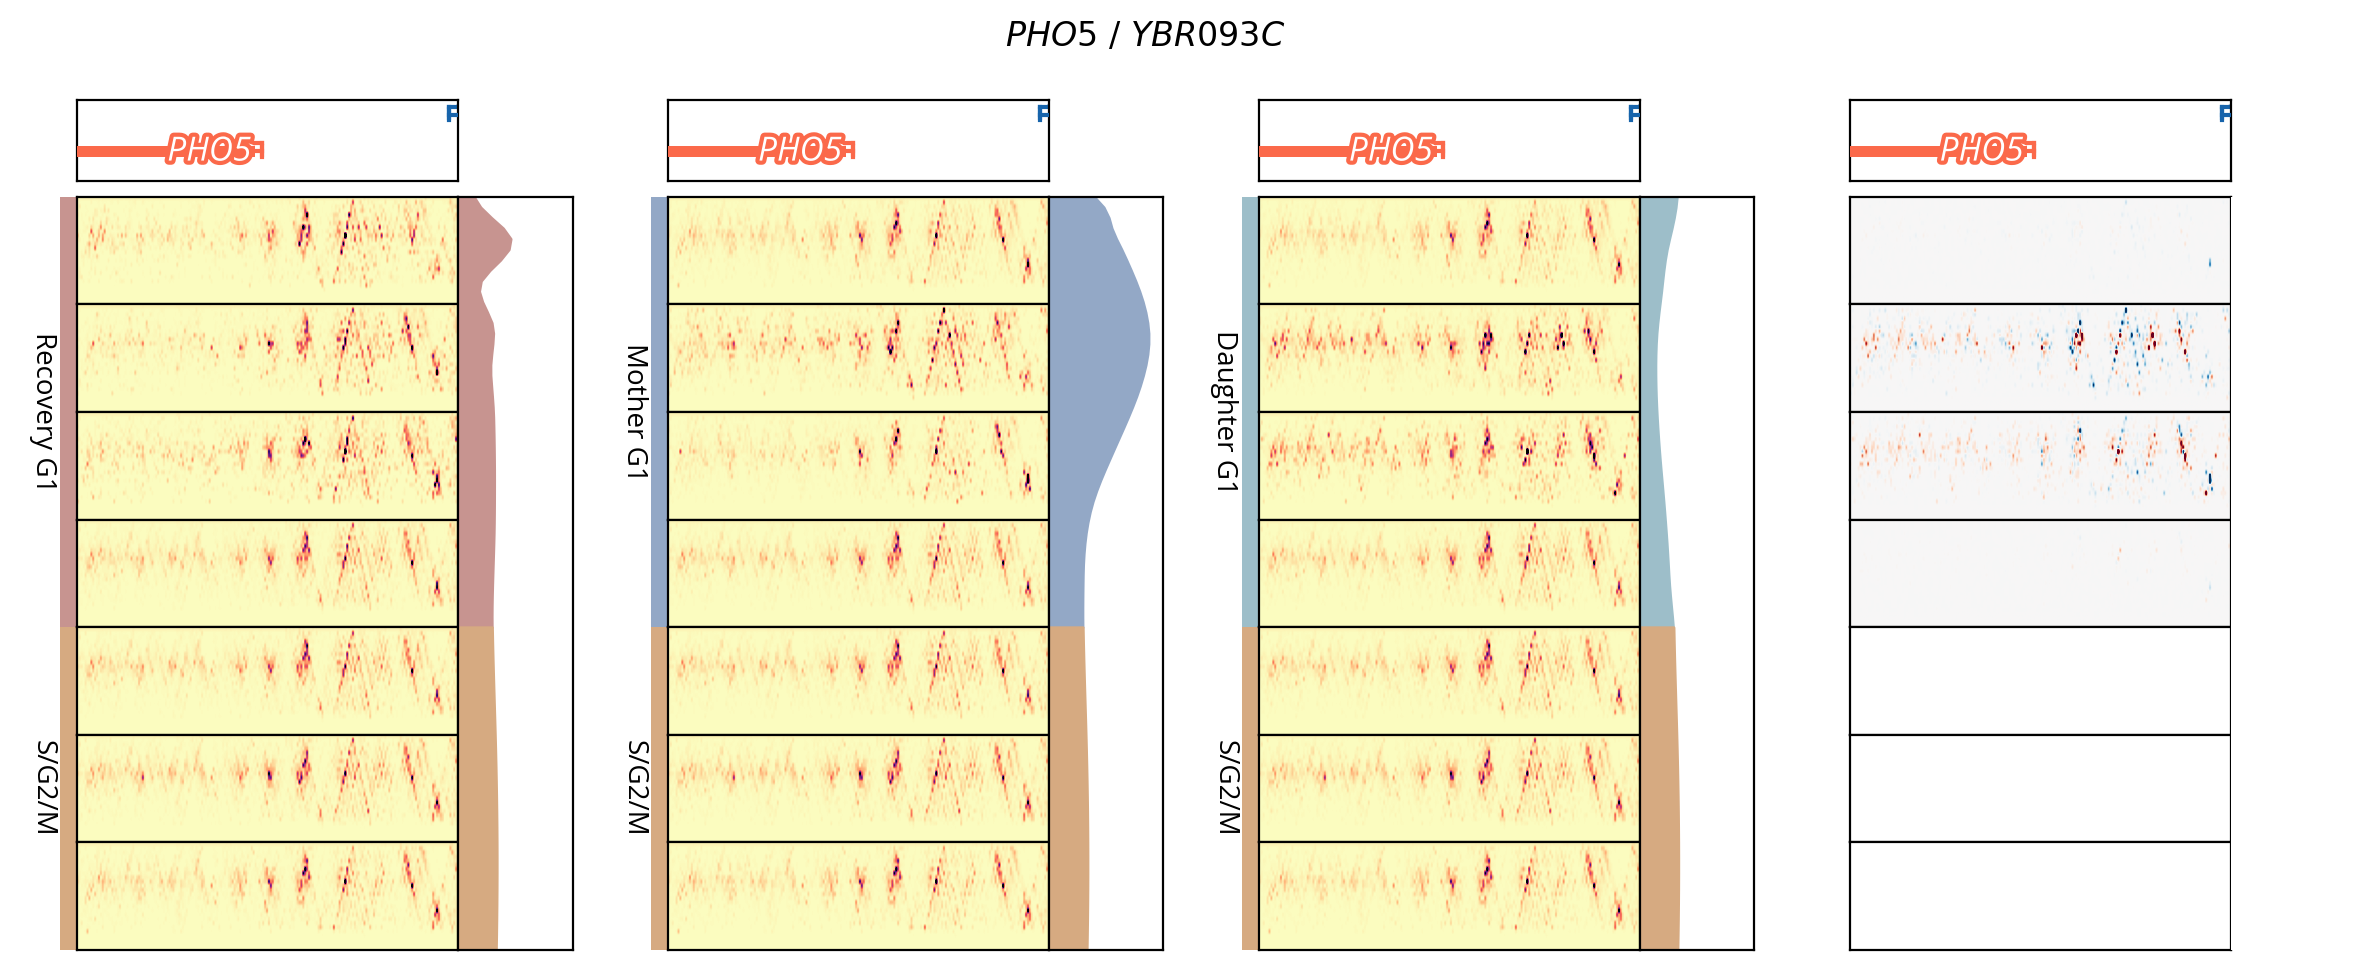

In [18]:
fig = genome_analysis.plot_gene('PHO5', config1, analysis)

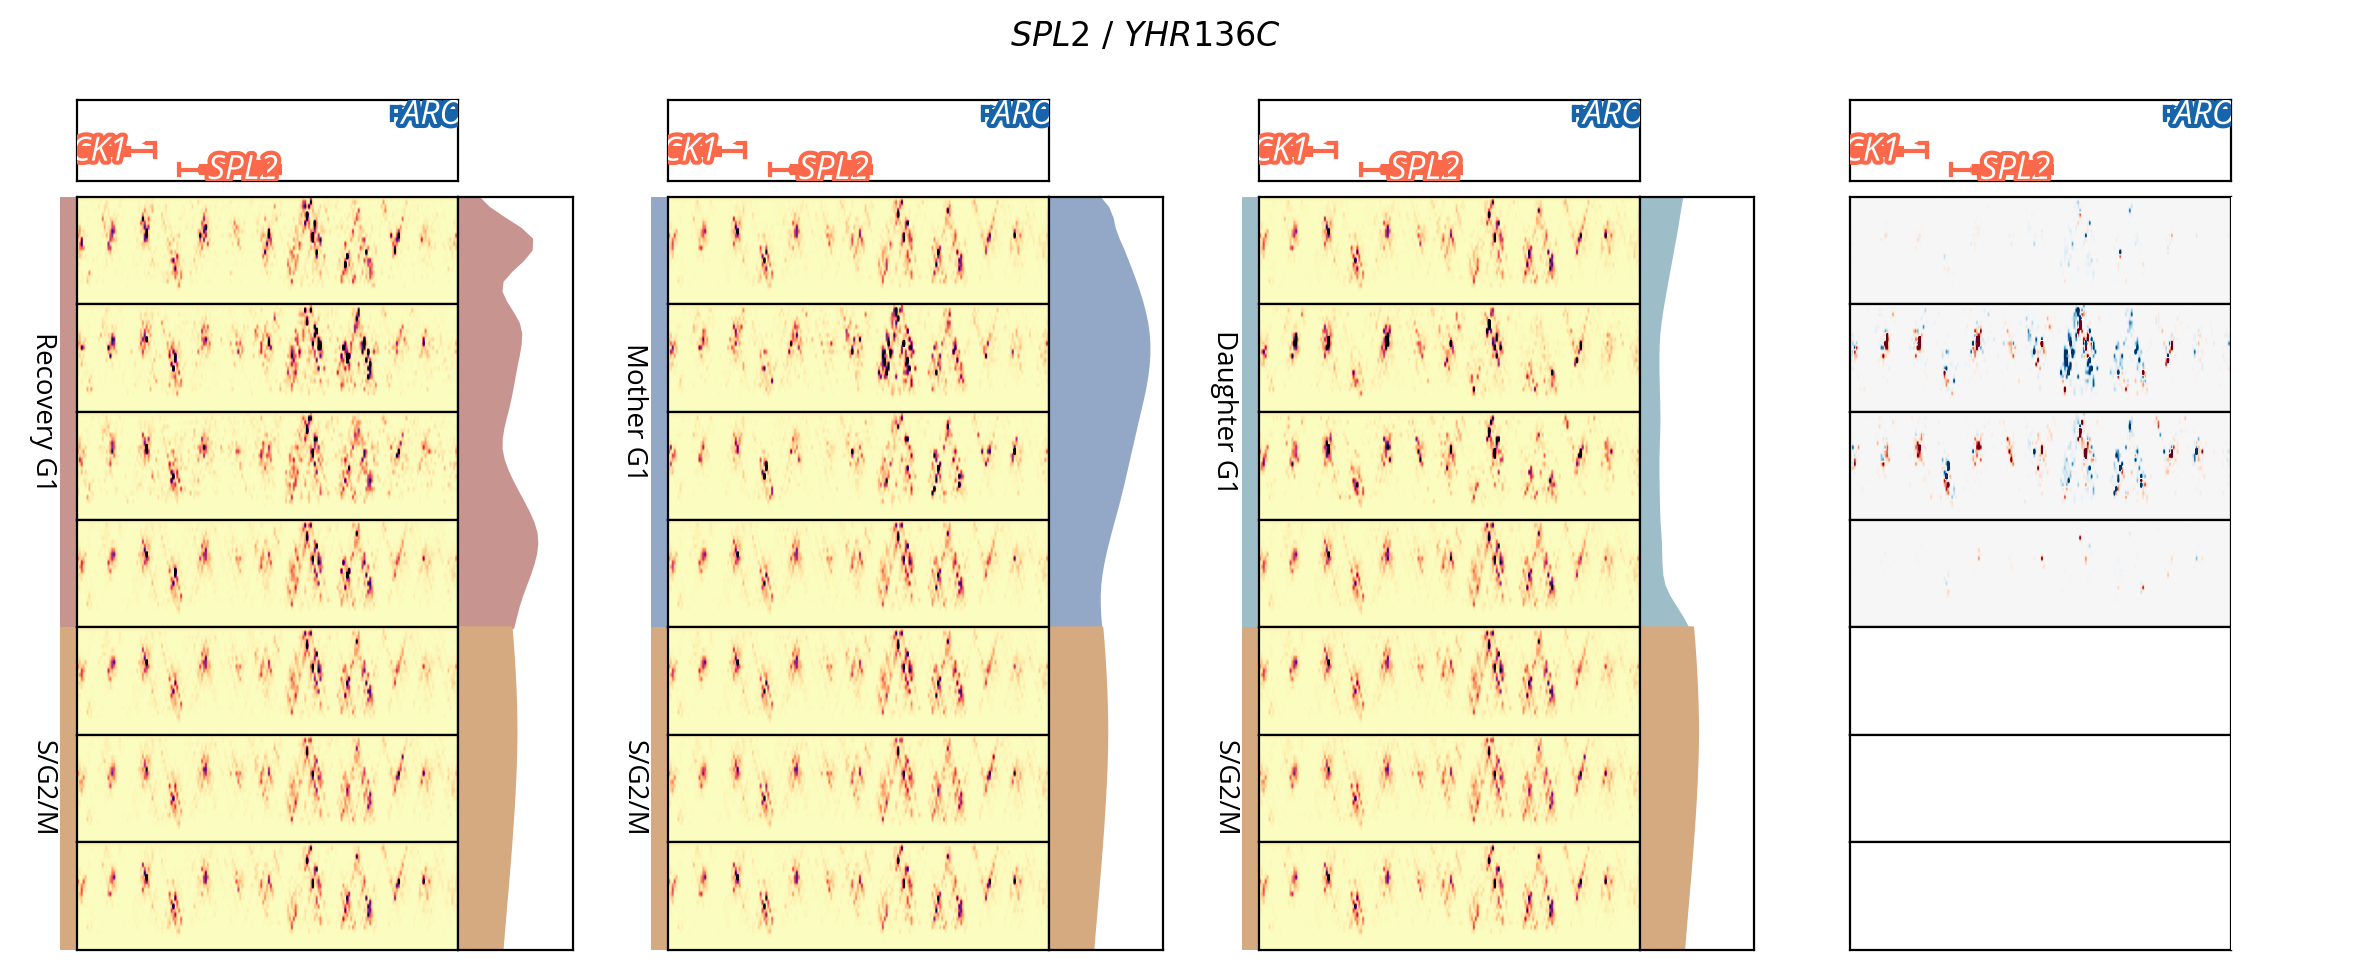

In [19]:
fig = genome_analysis.plot_gene('SPL2', config1, analysis)

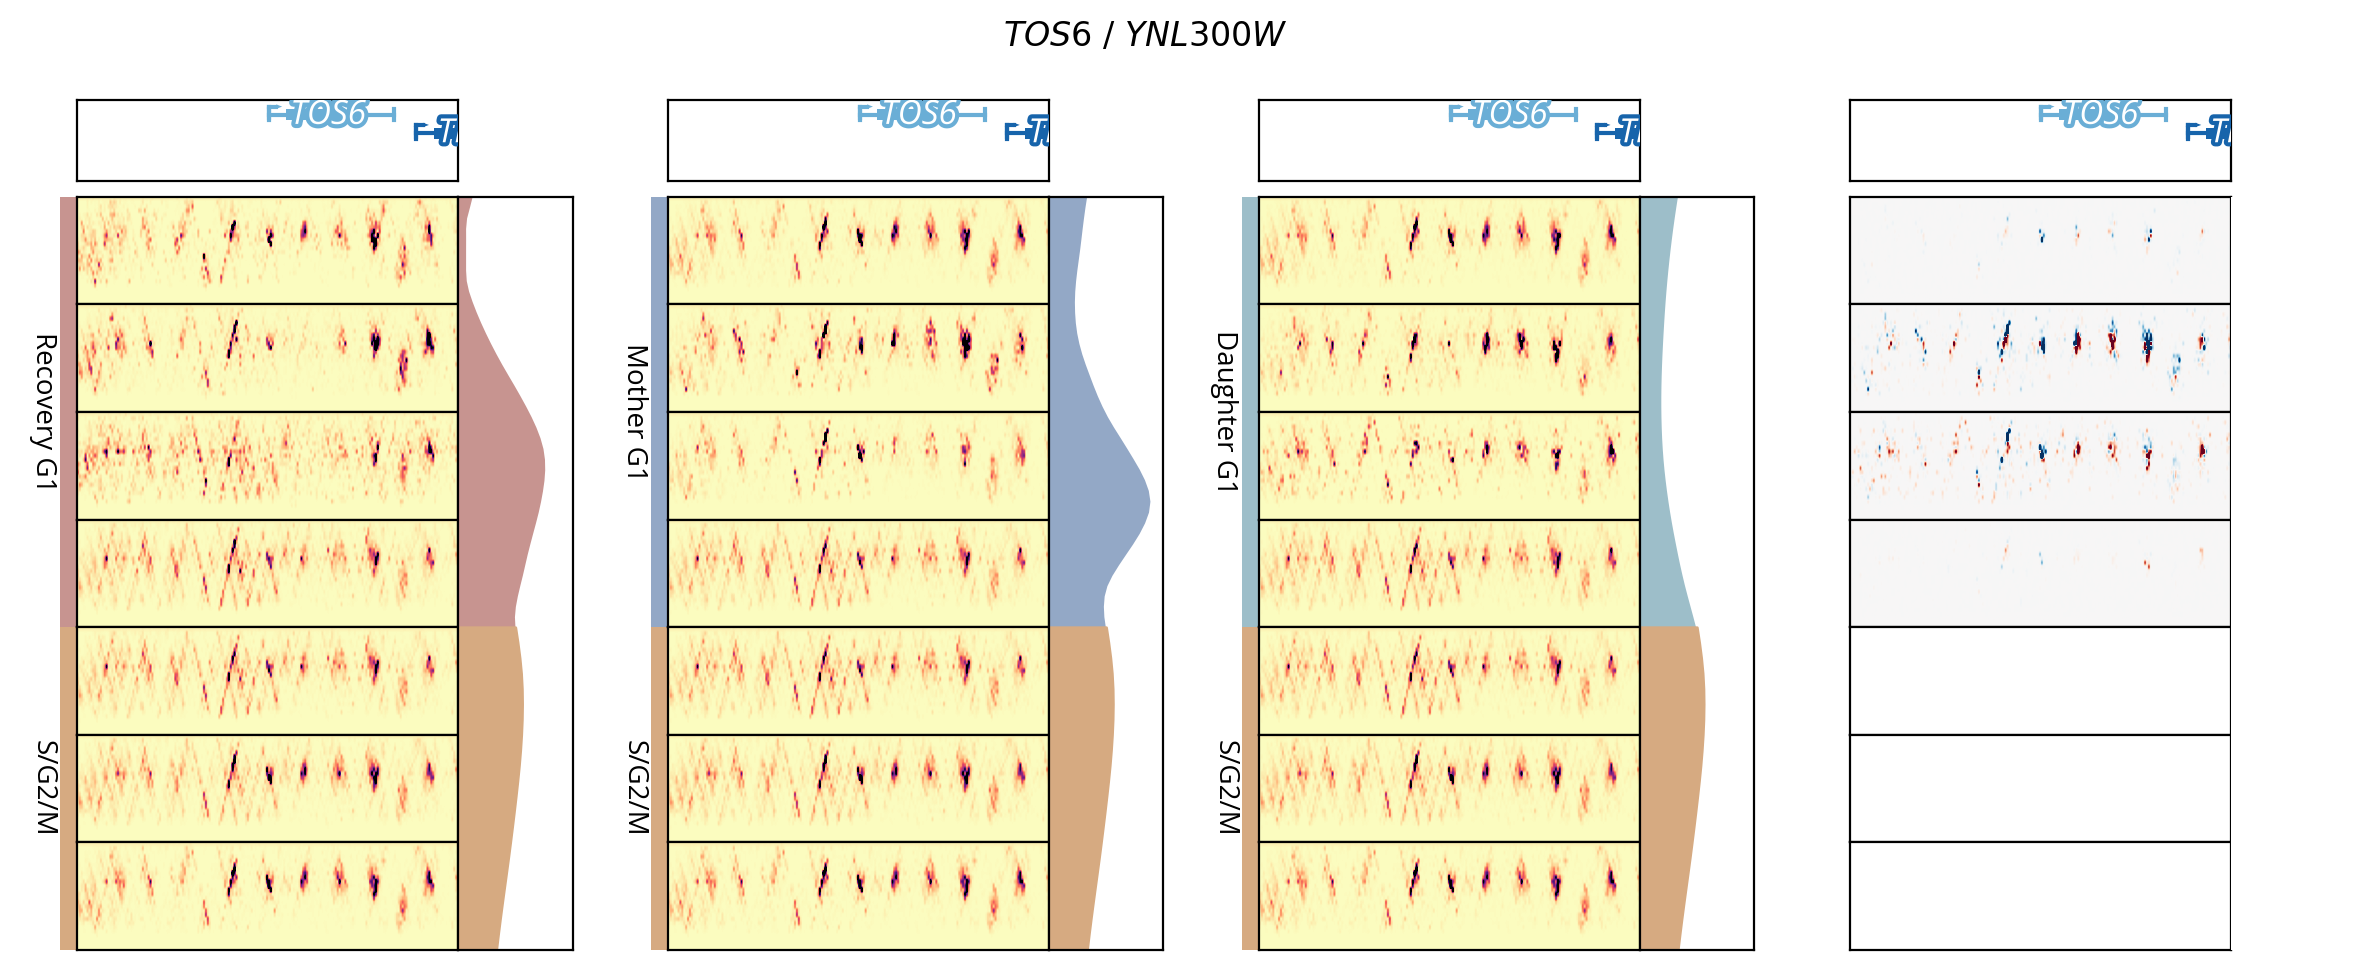

In [20]:
fig = genome_analysis.plot_gene('TOS6', config1, analysis)

In [165]:
mg1_only, mg1_and_dg1, dg1_only = analysis.retrieve_mg1_dg1_specific_genes(config1, 
    proportion_threshold=0.1)

Threshold of 1.1 > S/G2/M expression. There are:
93 Mother G1 specific genes
373 Daughter G1 specific genes
160 Mother and Daughter expressed genes


In [166]:
dg1_analysis.compute_g1_expression_sm_correlations(expressions_F, config1)

/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


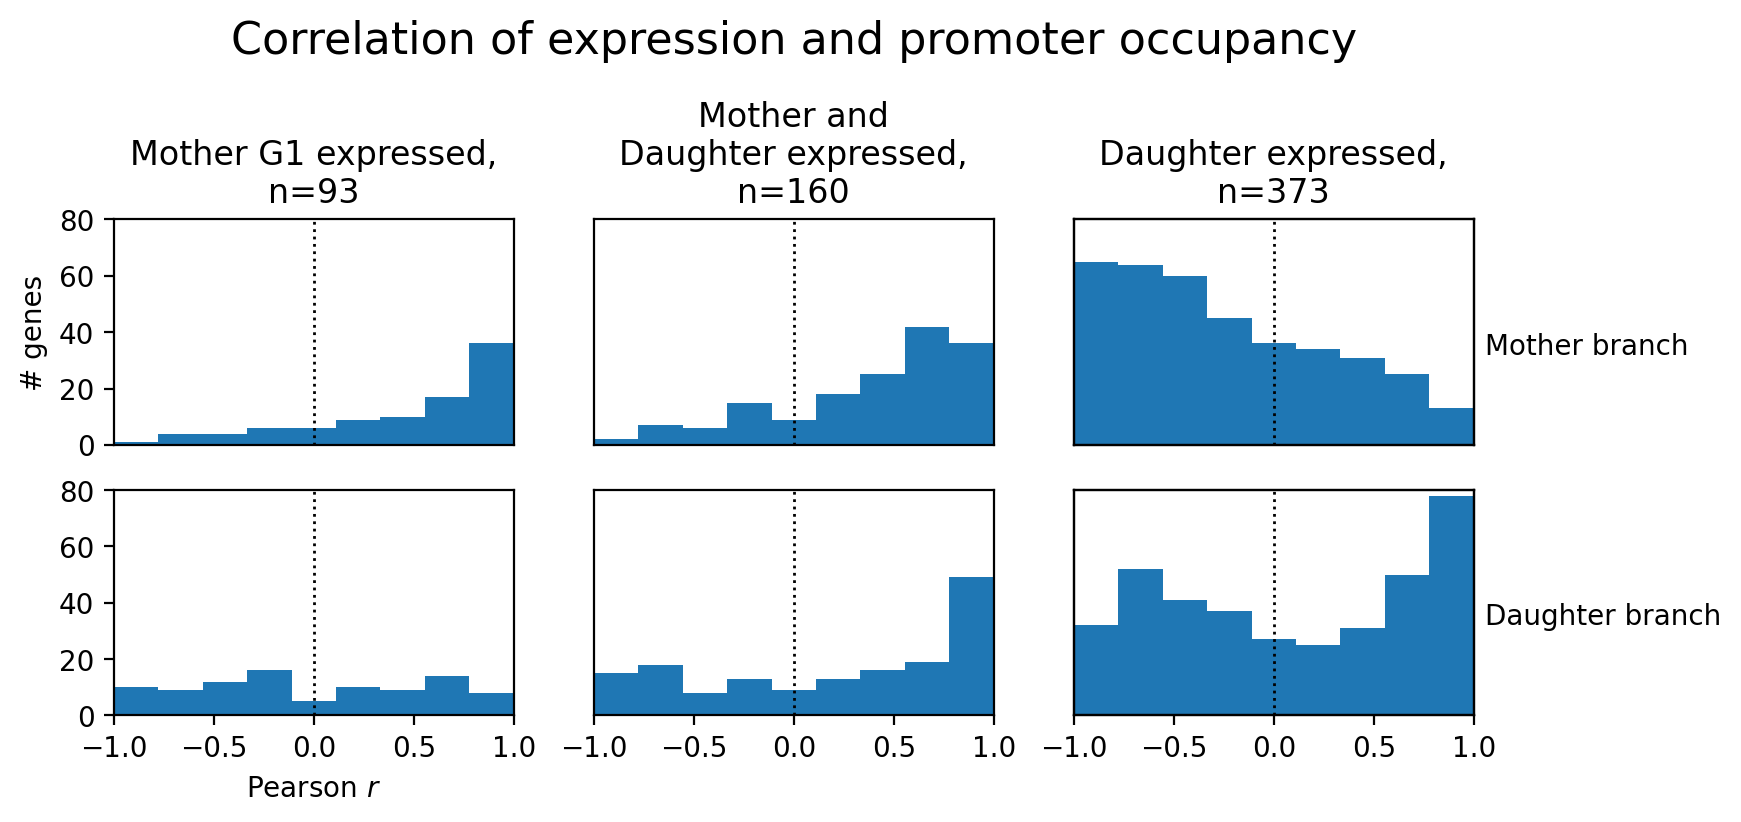

In [167]:
dg1_analysis.plot_tx_sm_correlation_histograms(mg1_only, mg1_and_dg1, dg1_only)

In [169]:
dg1_analysis.small_tx_bottom_correlations.loc[dg1_only].sort_values('correlation')\
    .join(genes[['gene']])

,correlation,p_value,gene
YNL011C,-0.967840,7.211796e-39,YNL011C
YPR191W,-0.961800,1.369654e-36,QCR2
YLR382C,-0.941222,6.387914e-31,NAM2
YMR087W,-0.907152,5.467250e-25,YMR087W
YJL020C,-0.904379,1.305141e-24,BBC1
...,...,...,...
YOR049C,0.980801,9.908468e-46,RSB1
YIL009W,0.982807,3.334348e-47,FAA3
YKR093W,0.986803,9.705072e-51,PTR2
YLR266C,0.992065,1.485845e-57,PDR8


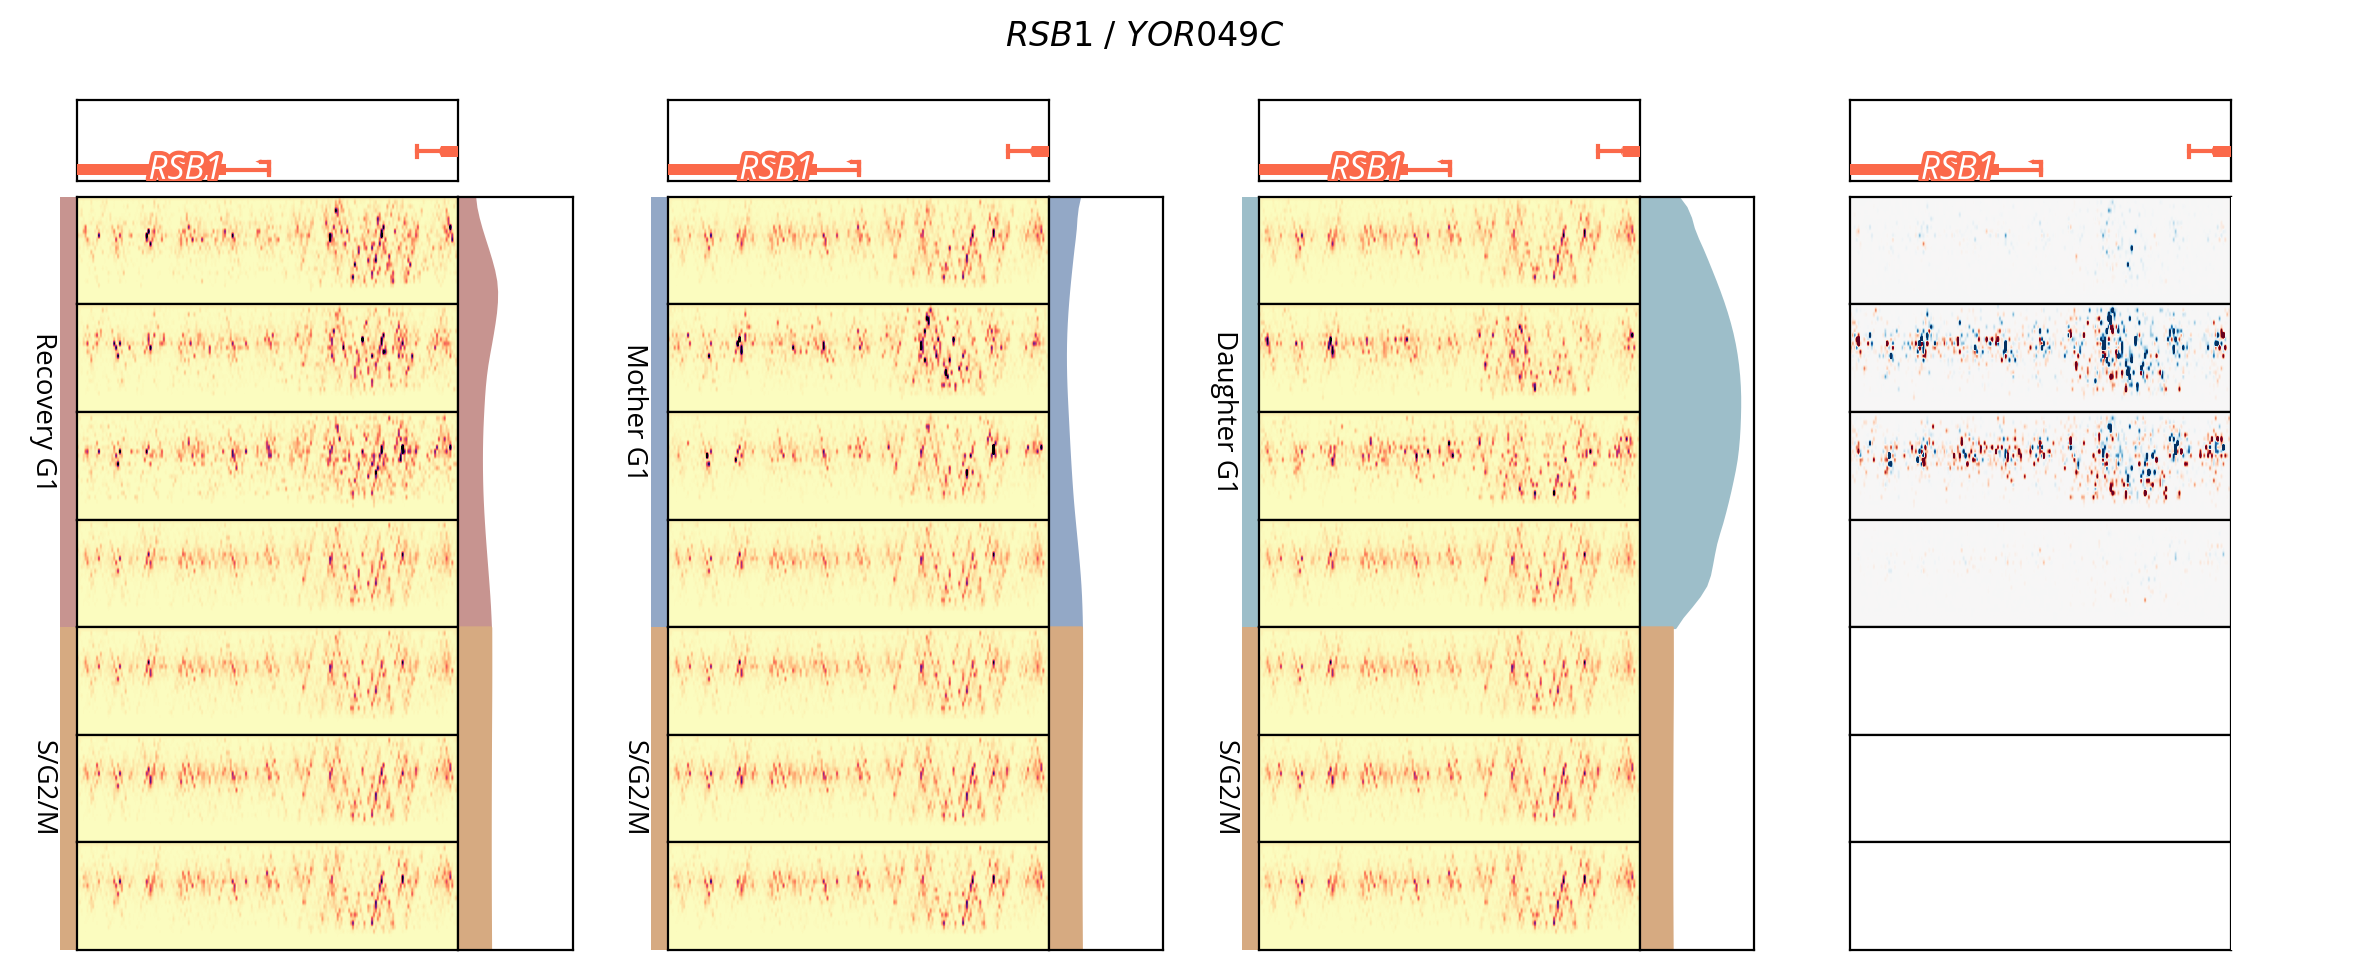

In [161]:
from src.sgd import get_orfname
gene_name = 'RSB1'
orfname = get_orfname(gene_name)
fig = genome_analysis.plot_gene(gene_name, config1, analysis)